# 08 – Car Parts Corrected-Data Augmentation Training

## Purpose

This notebook corrects the trunk and tailgate class definitions, applies controlled training-time augmentation, evaluates the improved model, and records the wheel-annotation review workflow that produced the input for Notebook 09.

## 1. Setup

In [1]:
%pip install -q ultralytics==8.4.138

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 2.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
from zipfile import ZipFile
import json
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from matplotlib.patches import Polygon
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available.")

GPU is not available.


## 2. Configuration and Paths

In [7]:
WORK_DIR = Path("/content/data")

CURRENT_DATA_ZIP = Path(
    "/content/drive/MyDrive/data/carparts-seg-processed.zip"
)

EXTERNAL_DATA_ZIP = Path(
    "/content/drive/MyDrive/data/external/hitl-carparts-processed.zip"
)

CURRENT_EXTRACT_DIR = WORK_DIR / "current-carparts"
EXTERNAL_EXTRACT_DIR = WORK_DIR / "external-carparts"

CURRENT_ROOT = CURRENT_EXTRACT_DIR / "carparts-seg-processed"
EXTERNAL_ROOT = EXTERNAL_EXTRACT_DIR

CORRECTED_DATA_DIR = WORK_DIR / "carparts-corrected-expanded"
CORRECTED_YAML = CORRECTED_DATA_DIR / "corrected-carparts.yaml"

CORRECTED_DATA_ZIP = Path(
    "/content/drive/MyDrive/data/carparts-corrected-expanded.zip"
)

RUNS_DIR = Path(
    "/content/drive/MyDrive/qaddir-training-results"
)

RUN_NAME = "carparts_yolo11n_corrected_augmented"

In [12]:
if not CORRECTED_DATA_DIR.exists():
    WORK_DIR.mkdir(parents=True, exist_ok=True)

    with ZipFile(CORRECTED_DATA_ZIP, "r") as zip_file:
        zip_file.extractall(WORK_DIR)

    print("Corrected dataset extracted.")
else:
    print("Corrected dataset is already available.")

Corrected dataset extracted.


In [12]:
MODEL_WEIGHTS = "yolo11n-seg.pt"

IMAGE_SIZE = 640
EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 8
WORKERS = 2
DEVICE = 0
SEED = 42

In [7]:
print("Current dataset:", CURRENT_DATA_ZIP)
print("External dataset:", EXTERNAL_DATA_ZIP)
print("Corrected dataset:", CORRECTED_DATA_DIR)
print("Training results:", RUNS_DIR / RUN_NAME)

Current dataset: /content/drive/MyDrive/data/carparts-seg-processed.zip
External dataset: /content/drive/MyDrive/data/external/hitl-carparts-processed.zip
Corrected dataset: /content/data/carparts-corrected-expanded
Training results: /content/drive/MyDrive/qaddir-training-results/carparts_yolo11n_corrected_augmented


## 3. Data Loading

In [9]:
if CURRENT_EXTRACT_DIR.exists():
    shutil.rmtree(CURRENT_EXTRACT_DIR)

if EXTERNAL_EXTRACT_DIR.exists():
    shutil.rmtree(EXTERNAL_EXTRACT_DIR)

CURRENT_EXTRACT_DIR.mkdir(parents=True)
EXTERNAL_EXTRACT_DIR.mkdir(parents=True)

with ZipFile(CURRENT_DATA_ZIP, "r") as zip_file:
    zip_file.extractall(CURRENT_EXTRACT_DIR)

with ZipFile(EXTERNAL_DATA_ZIP, "r") as zip_file:
    zip_file.extractall(EXTERNAL_EXTRACT_DIR)

print("Current dataset extracted.")
print("External dataset extracted.")

Current dataset extracted.
External dataset extracted.


In [10]:
CURRENT_YAML = (
    CURRENT_ROOT
    / "carparts-seg-processed.yaml"
)

EXTERNAL_YAML = (
    EXTERNAL_ROOT
    / "hitl-carparts.yaml"
)

with CURRENT_YAML.open("r") as file:
    current_config = yaml.safe_load(file)

with EXTERNAL_YAML.open("r") as file:
    external_config = yaml.safe_load(file)

current_classes = current_config["names"]
external_classes = external_config["names"]

if isinstance(current_classes, dict):
    current_classes = [
        current_classes[index]
        for index in range(len(current_classes))
    ]

if isinstance(external_classes, dict):
    external_classes = [
        external_classes[index]
        for index in range(len(external_classes))
    ]

print("Current classes:", current_classes)
print("External classes:", external_classes)

Current classes: ['back_bumper', 'back_door', 'back_glass', 'back_light', 'front_bumper', 'front_door', 'front_glass', 'front_light', 'hood', 'side_mirror', 'tailgate', 'trunk', 'wheel']
External classes: ['back_bumper', 'back_door', 'back_glass', 'back_light', 'front_bumper', 'front_door', 'front_glass', 'front_light', 'hood', 'side_mirror', 'tailgate', 'trunk', 'wheel']


## 4. Data Validation

In [10]:
class_comparison_df = pd.DataFrame({
    "Class ID": range(len(current_classes)),
    "Current Class": current_classes,
    "External Class": external_classes
})

class_comparison_df["Match"] = (
    class_comparison_df["Current Class"]
    == class_comparison_df["External Class"]
)

display(class_comparison_df)

,Class ID,Current Class,External Class,Match
0,0,back_bumper,back_bumper,True
1,1,back_door,back_door,True
2,2,back_glass,back_glass,True
3,3,back_light,back_light,True
4,4,front_bumper,front_bumper,True
5,5,front_door,front_door,True
6,6,front_glass,front_glass,True
7,7,front_light,front_light,True
8,8,hood,hood,True
9,9,side_mirror,side_mirror,True


In [11]:
datasets = {
    "Current Train": CURRENT_ROOT / "labels" / "train",
    "External Train": EXTERNAL_ROOT / "labels" / "train"
}

class_ids_to_check = {
    10: "tailgate",
    11: "trunk"
}

class_count_rows = []

for dataset_name, labels_dir in datasets.items():
    for class_id, class_name in class_ids_to_check.items():
        instance_count = 0

        for label_path in labels_dir.glob("*.txt"):
            for line in label_path.read_text().splitlines():
                if line.strip() and int(line.split()[0]) == class_id:
                    instance_count += 1

        class_count_rows.append({
            "Dataset": dataset_name,
            "Class ID": class_id,
            "Current Name": class_name,
            "Instances": instance_count
        })

class_count_df = pd.DataFrame(class_count_rows)
display(class_count_df)

,Dataset,Class ID,Current Name,Instances
0,Current Train,10,tailgate,70
1,Current Train,11,trunk,121
2,External Train,10,tailgate,0
3,External Train,11,trunk,300


## 5. Analysis and Visualization

In [12]:
final_classes = current_classes.copy()

final_classes[10] = "trunk_or_tailgate"
final_classes[11] = "truck_bed"

class_name_changes_df = pd.DataFrame({
    "Class ID": [10, 11],
    "Previous Name": [
        current_classes[10],
        current_classes[11]
    ],
    "Final Name": [
        final_classes[10],
        final_classes[11]
    ]
})

display(class_name_changes_df)

,Class ID,Previous Name,Final Name
0,10,tailgate,trunk_or_tailgate
1,11,trunk,truck_bed


In [13]:
current_counts = (
    class_count_df[class_count_df["Dataset"] == "Current Train"]
    .set_index("Class ID")["Instances"]
)

external_counts = (
    class_count_df[class_count_df["Dataset"] == "External Train"]
    .set_index("Class ID")["Instances"]
)

corrected_distribution_df = pd.DataFrame({
    "Class": [
        "trunk_or_tailgate",
        "truck_bed"
    ],
    "Current Train": [
        current_counts[10],
        current_counts[11]
    ],
    "External Train": [
        external_counts[11],
        0
    ]
})

corrected_distribution_df["Combined Train"] = (
    corrected_distribution_df["Current Train"]
    + corrected_distribution_df["External Train"]
)

display(corrected_distribution_df)

,Class,Current Train,External Train,Combined Train
0,trunk_or_tailgate,70,300,370
1,truck_bed,121,0,121


The corrected mapping assigns external `trunk` polygons to `trunk_or_tailgate` because their visual definition matches class 10 in the current dataset. The current class 11 is renamed to `truck_bed` because it represents pickup cargo-bed regions. The number of classes remains unchanged at 13.

## 6. Processing

In [14]:
if CORRECTED_DATA_DIR.exists():
    shutil.rmtree(CORRECTED_DATA_DIR)

shutil.copytree(
    CURRENT_ROOT,
    CORRECTED_DATA_DIR
)

print("Current dataset copied.")

Current dataset copied.


In [15]:
external_images_dir = EXTERNAL_ROOT / "images" / "train"
corrected_images_dir = CORRECTED_DATA_DIR / "images" / "train"

external_image_count = 0

for image_path in external_images_dir.iterdir():
    shutil.copy2(
        image_path,
        corrected_images_dir / image_path.name
    )

    external_image_count += 1

print("External training images copied:", external_image_count)

External training images copied: 698


In [16]:
external_labels_dir = EXTERNAL_ROOT / "labels" / "train"
corrected_labels_dir = CORRECTED_DATA_DIR / "labels" / "train"

external_label_count = 0
remapped_instance_count = 0

for label_path in external_labels_dir.glob("*.txt"):
    corrected_lines = []

    for line in label_path.read_text().splitlines():
        values = line.split()

        if values[0] == "11":
            values[0] = "10"
            remapped_instance_count += 1

        corrected_lines.append(" ".join(values))

    output_label_path = corrected_labels_dir / label_path.name

    output_label_path.write_text(
        "\n".join(corrected_lines) + "\n"
    )

    external_label_count += 1

print("External training labels copied:", external_label_count)
print("External trunk instances remapped:", remapped_instance_count)

External training labels copied: 698
External trunk instances remapped: 300


In [17]:
corrected_config = current_config.copy()

corrected_config["path"] = str(CORRECTED_DATA_DIR)
corrected_config["names"] = final_classes

with CORRECTED_YAML.open("w") as file:
    yaml.safe_dump(
        corrected_config,
        file,
        sort_keys=False
    )

print(CORRECTED_YAML.read_text())

path: /content/data/carparts-corrected-expanded
train: images/train
val: images/val
test: images/test
names:
- back_bumper
- back_door
- back_glass
- back_light
- front_bumper
- front_door
- front_glass
- front_light
- hood
- side_mirror
- trunk_or_tailgate
- truck_bed
- wheel



In [18]:
validation_rows = []
split_image_names = {}

for split in ["train", "val", "test"]:
    images_dir = CORRECTED_DATA_DIR / "images" / split
    labels_dir = CORRECTED_DATA_DIR / "labels" / split

    image_files = [
        path for path in images_dir.iterdir()
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    label_files = list(labels_dir.glob("*.txt"))

    image_names = {path.stem for path in image_files}
    label_names = {path.stem for path in label_files}

    split_image_names[split] = image_names

    polygon_count = sum(
        len(path.read_text().splitlines())
        for path in label_files
    )

    empty_label_count = sum(
        not path.read_text().strip()
        for path in label_files
    )

    validation_rows.append({
        "Split": split,
        "Images": len(image_files),
        "Labels": len(label_files),
        "Polygons": polygon_count,
        "Missing Pairs": len(image_names ^ label_names),
        "Empty Labels": empty_label_count
    })

corrected_validation_df = pd.DataFrame(validation_rows)
display(corrected_validation_df)

,Split,Images,Labels,Polygons,Missing Pairs,Empty Labels
0,train,3269,3269,20727,0,0
1,val,561,561,3096,0,0
2,test,554,554,2967,0,0


In [19]:
corrected_class_counts = {
    10: 0,
    11: 0
}

external_class_11_count = 0

for label_path in (
    CORRECTED_DATA_DIR / "labels" / "train"
).glob("*.txt"):

    for line in label_path.read_text().splitlines():
        class_id = int(line.split()[0])

        if class_id in corrected_class_counts:
            corrected_class_counts[class_id] += 1

        if (
            label_path.stem.startswith("hitl_")
            and class_id == 11
        ):
            external_class_11_count += 1

corrected_class_df = pd.DataFrame({
    "Class ID": [10, 11],
    "Class": [
        final_classes[10],
        final_classes[11]
    ],
    "Train Instances": [
        corrected_class_counts[10],
        corrected_class_counts[11]
    ]
})

display(corrected_class_df)

print(
    "External instances still assigned to class 11:",
    external_class_11_count
)

,Class ID,Class,Train Instances
0,10,trunk_or_tailgate,370
1,11,truck_bed,121


External instances still assigned to class 11: 0


In [20]:
print(
    "Train and validation overlap:",
    len(split_image_names["train"] & split_image_names["val"])
)

print(
    "Train and test overlap:",
    len(split_image_names["train"] & split_image_names["test"])
)

print(
    "Validation and test overlap:",
    len(split_image_names["val"] & split_image_names["test"])
)

Train and validation overlap: 0
Train and test overlap: 0
Validation and test overlap: 0


In [21]:
zip_base_path = CORRECTED_DATA_ZIP.with_suffix("")

shutil.make_archive(
    str(zip_base_path),
    "zip",
    root_dir=CORRECTED_DATA_DIR.parent,
    base_dir=CORRECTED_DATA_DIR.name
)

print("Saved dataset:", CORRECTED_DATA_ZIP)
print("Size (MB):", round(CORRECTED_DATA_ZIP.stat().st_size / 1_000_000, 1))

Saved dataset: /content/drive/MyDrive/data/carparts-corrected-expanded.zip
Size (MB): 645.2


**Define Controlled Training-Time Augmentation**

In [23]:
augmentation_config = {
    "hsv_h": 0.01,
    "hsv_s": 0.30,
    "hsv_v": 0.30,
    "degrees": 10.0,
    "translate": 0.05,
    "scale": 0.15,
    "fliplr": 0.50,
    "flipud": 0.0,
    "mosaic": 0.20,
    "mixup": 0.0,
    "cutmix": 0.0,
    "copy_paste": 0.0
}

augmentation_df = pd.DataFrame(
    augmentation_config.items(),
    columns=["Setting", "Value"]
)

display(augmentation_df)

,Setting,Value
0,hsv_h,0.01
1,hsv_s,0.30
2,hsv_v,0.30
3,degrees,10.00
4,translate,0.05
5,scale,0.15
6,fliplr,0.50
7,flipud,0.00
8,mosaic,0.20
9,mixup,0.00


In [24]:
model = YOLO(MODEL_WEIGHTS)

training_results = model.train(
    data=str(CORRECTED_YAML),
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,
    device=DEVICE,
    seed=SEED,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    close_mosaic=10,
    plots=True,
    save=True,
    save_period=5,
    **augmentation_config
)

New https://pypi.org/project/ultralytics/8.4.144 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/carparts-corrected-expanded/corrected-carparts.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4,

## 7. Results

### 7.1 Validate the Best Model

In [26]:
best_model_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

best_model = YOLO(str(best_model_path))

validation_results = best_model.val(
    data=str(CORRECTED_YAML),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_validation",
    plots=True,
    exist_ok=True
)

print("Best model:", best_model_path)
print("Validation results:", validation_results.save_dir)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,837,103 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 917.7±329.3 MB/s, size: 34.6 KB)
val: Scanning /content/data/carparts-corrected-expanded/labels/val.cache... 561 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 561/561 123.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 5.5it/s 13.0s
                   all        561       3096      0.865      0.873        0.9       0.74      0.877      0.881      0.906      0.705
           back_bumper        132        132      0.895      0.902      0.972      0.796      0.894      0.895      0.973      0.739
             back_door        245        245      0.794      0.935      0.918       0.82      0.793      0.931      0.907      0.769
            back_gl

### 7.2 Review Training Curves

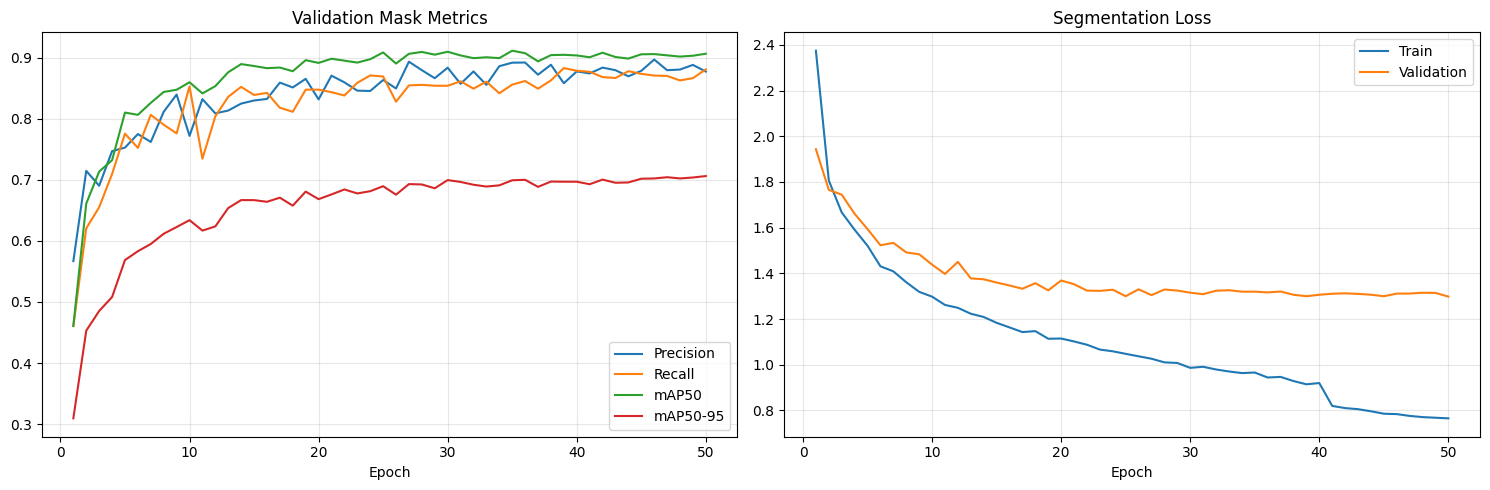

In [28]:
results_df = pd.read_csv(RUNS_DIR / RUN_NAME / "results.csv")
results_df.columns = results_df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(results_df["epoch"], results_df["metrics/precision(M)"], label="Precision")
axes[0].plot(results_df["epoch"], results_df["metrics/recall(M)"], label="Recall")
axes[0].plot(results_df["epoch"], results_df["metrics/mAP50(M)"], label="mAP50")
axes[0].plot(results_df["epoch"], results_df["metrics/mAP50-95(M)"], label="mAP50-95")
axes[0].set_title("Validation Mask Metrics")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(results_df["epoch"], results_df["train/seg_loss"], label="Train")
axes[1].plot(results_df["epoch"], results_df["val/seg_loss"], label="Validation")
axes[1].set_title("Segmentation Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Training Findings

Training converged successfully over 50 epochs. The training and validation losses decreased together during the early epochs, while the validation segmentation loss became stable later in training. A small train-validation gap appeared toward the end, indicating mild overfitting rather than insufficient training.

The best model achieved a validation Mask Precision of 0.877, Mask Recall of 0.881, Mask mAP50 of 0.906, and Mask mAP50-95 of 0.705. This represents a clear improvement over the original baseline across all segmentation metrics and all classes.

The wheel class improved but remained the weakest class, with a Mask Recall of 0.582 and Mask mAP50-95 of 0.335. Therefore, additional epochs or learning-rate changes are not currently justified. The next step is a class-focused visual error analysis of wheel predictions before deciding whether targeted data improvement is required.

### 7.4 Inspect Wheel Predictions

In [13]:
import random

wheel_class_id = 12
val_labels_dir = CORRECTED_DATA_DIR / "labels" / "val"
val_images_dir = CORRECTED_DATA_DIR / "images" / "val"

wheel_images = []

for label_path in val_labels_dir.glob("*.txt"):
    class_ids = [
        int(line.split()[0])
        for line in label_path.read_text().splitlines()
    ]

    if wheel_class_id in class_ids:
        wheel_images.append(val_images_dir / f"{label_path.stem}.jpg")

random.seed(SEED)
wheel_samples = random.sample(wheel_images, 6)

wheel_predictions = best_model.predict(
    source=[str(path) for path in wheel_samples],
    classes=[wheel_class_id],
    conf=0.25,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for axis, prediction in zip(axes.flat, wheel_predictions):
    axis.imshow(prediction.plot()[..., ::-1])
    axis.axis("off")

plt.tight_layout()
plt.show()

### 7.5 Wheel Prediction Findings

The model reliably detected clear wheels in side-view images, often with high confidence. Performance was weaker for small, partially visible, occluded, frontal, and rear-view wheels. Some predictions also showed imprecise masks or insufficient separation between multiple wheels.

These observations suggest that the weak wheel metrics are related to difficult viewpoints, instance-mask quality, and potentially incomplete wheel annotations rather than a complete failure to recognize the class. The wheel ground-truth annotations should therefore be compared with the predictions before selecting a targeted improvement strategy.

### 7.6 Compare Wheel Ground Truth and Predictions

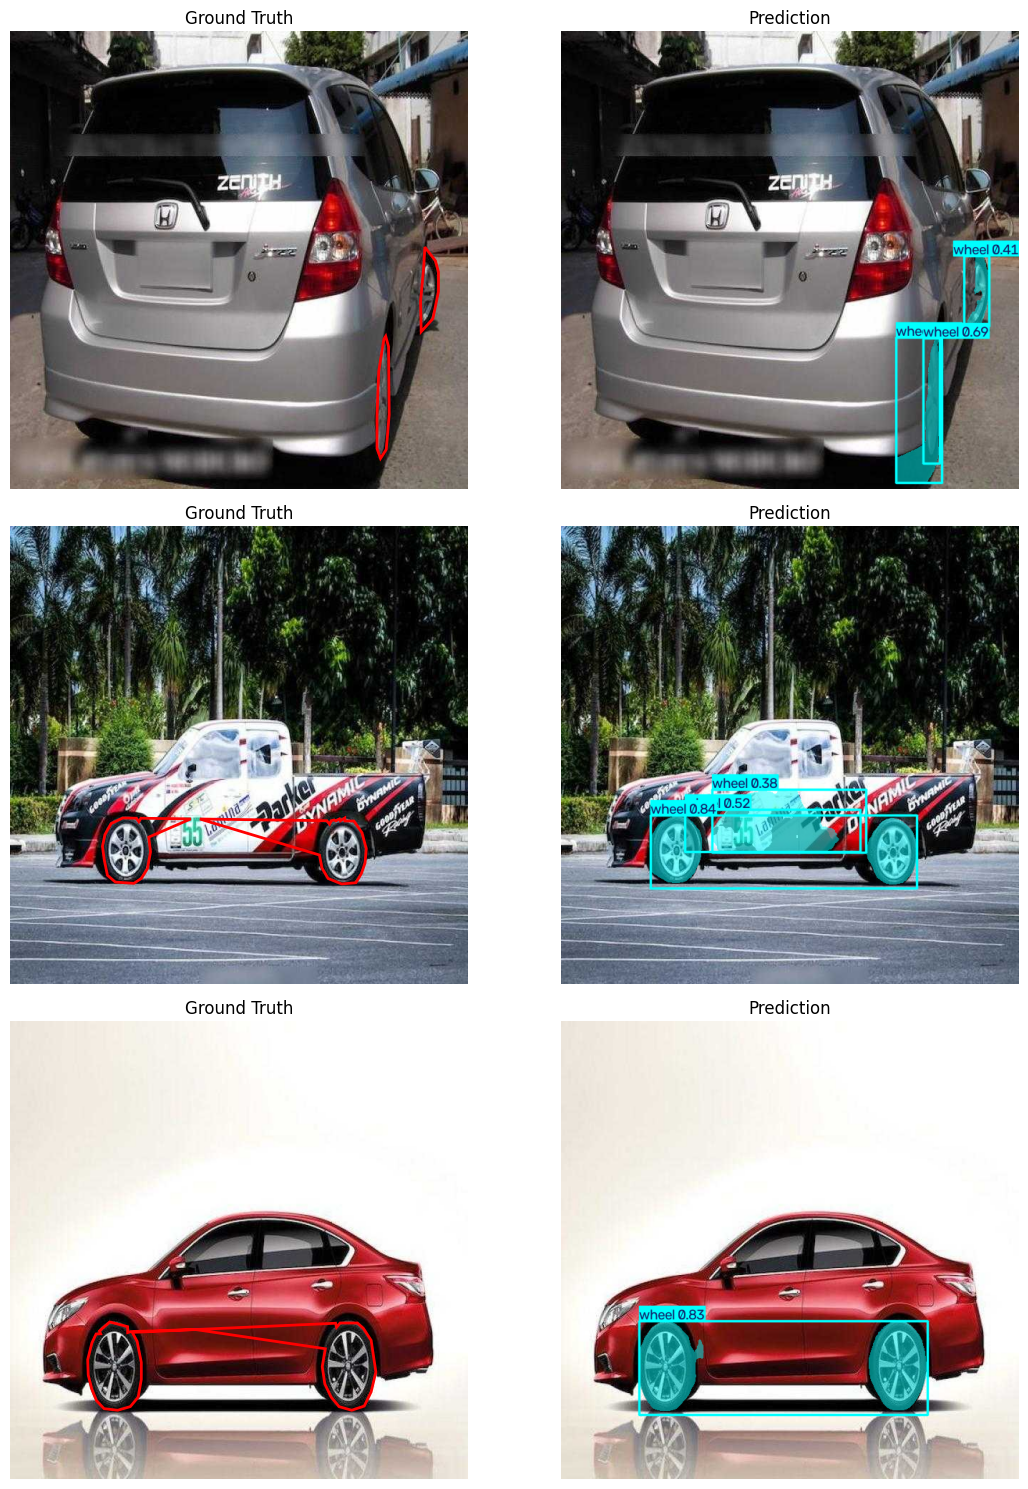

In [30]:
from matplotlib.patches import Polygon

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row in range(3):
    image_path = wheel_samples[row]
    prediction = wheel_predictions[row]

    image = np.array(Image.open(image_path).convert("RGB"))
    height, width = image.shape[:2]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Ground Truth")

    label_path = val_labels_dir / f"{image_path.stem}.txt"

    for line in label_path.read_text().splitlines():
        values = list(map(float, line.split()))

        if int(values[0]) == wheel_class_id:
            points = np.array(values[1:]).reshape(-1, 2)
            points = points * [width, height]

            axes[row, 0].add_patch(
                Polygon(
                    points,
                    fill=False,
                    edgecolor="red",
                    linewidth=2
                )
            )

    axes[row, 1].imshow(prediction.plot()[..., ::-1])
    axes[row, 1].set_title("Prediction")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

### 7.7 Wheel Annotation Findings

The ground-truth comparison revealed inconsistent wheel annotation styles. Some images represent each visible wheel as a separate instance, while others connect multiple wheels through a single polygon crossing the vehicle body.

The model reproduced parts of this inconsistent annotation pattern by occasionally grouping multiple wheels into one prediction. Therefore, the weak wheel mAP50-95 cannot be attributed solely to model performance. Semantic annotation inconsistency is also affecting both training and validation.

Each visible wheel should be represented as a separate instance polygon covering only the visible wheel area. Wheel annotations should be reviewed before applying additional wheel augmentation or model tuning.

## 8. Decisions and Next Steps

### 8.1 Audit Suspicious Wheel Annotations

In [31]:
wheel_audit = []

for split in ["train", "val"]:
    labels_dir = CORRECTED_DATA_DIR / "labels" / split

    for label_path in labels_dir.glob("*.txt"):
        for line_number, line in enumerate(label_path.read_text().splitlines()):
            values = list(map(float, line.split()))

            if int(values[0]) != wheel_class_id:
                continue

            x_points = values[1::2]
            y_points = values[2::2]

            polygon_width = max(x_points) - min(x_points)
            polygon_height = max(y_points) - min(y_points)
            aspect_ratio = polygon_width / polygon_height

            wheel_audit.append({
                "Split": split,
                "Label": label_path.name,
                "Line": line_number,
                "Aspect Ratio": aspect_ratio,
                "Suspicious": aspect_ratio > 2.5
            })

wheel_audit_df = pd.DataFrame(wheel_audit)

display(
    wheel_audit_df.groupby(["Split", "Suspicious"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "Normal", True: "Suspicious"})
)

Suspicious,Normal,Suspicious
Split,,
train,1741,98
val,112,29


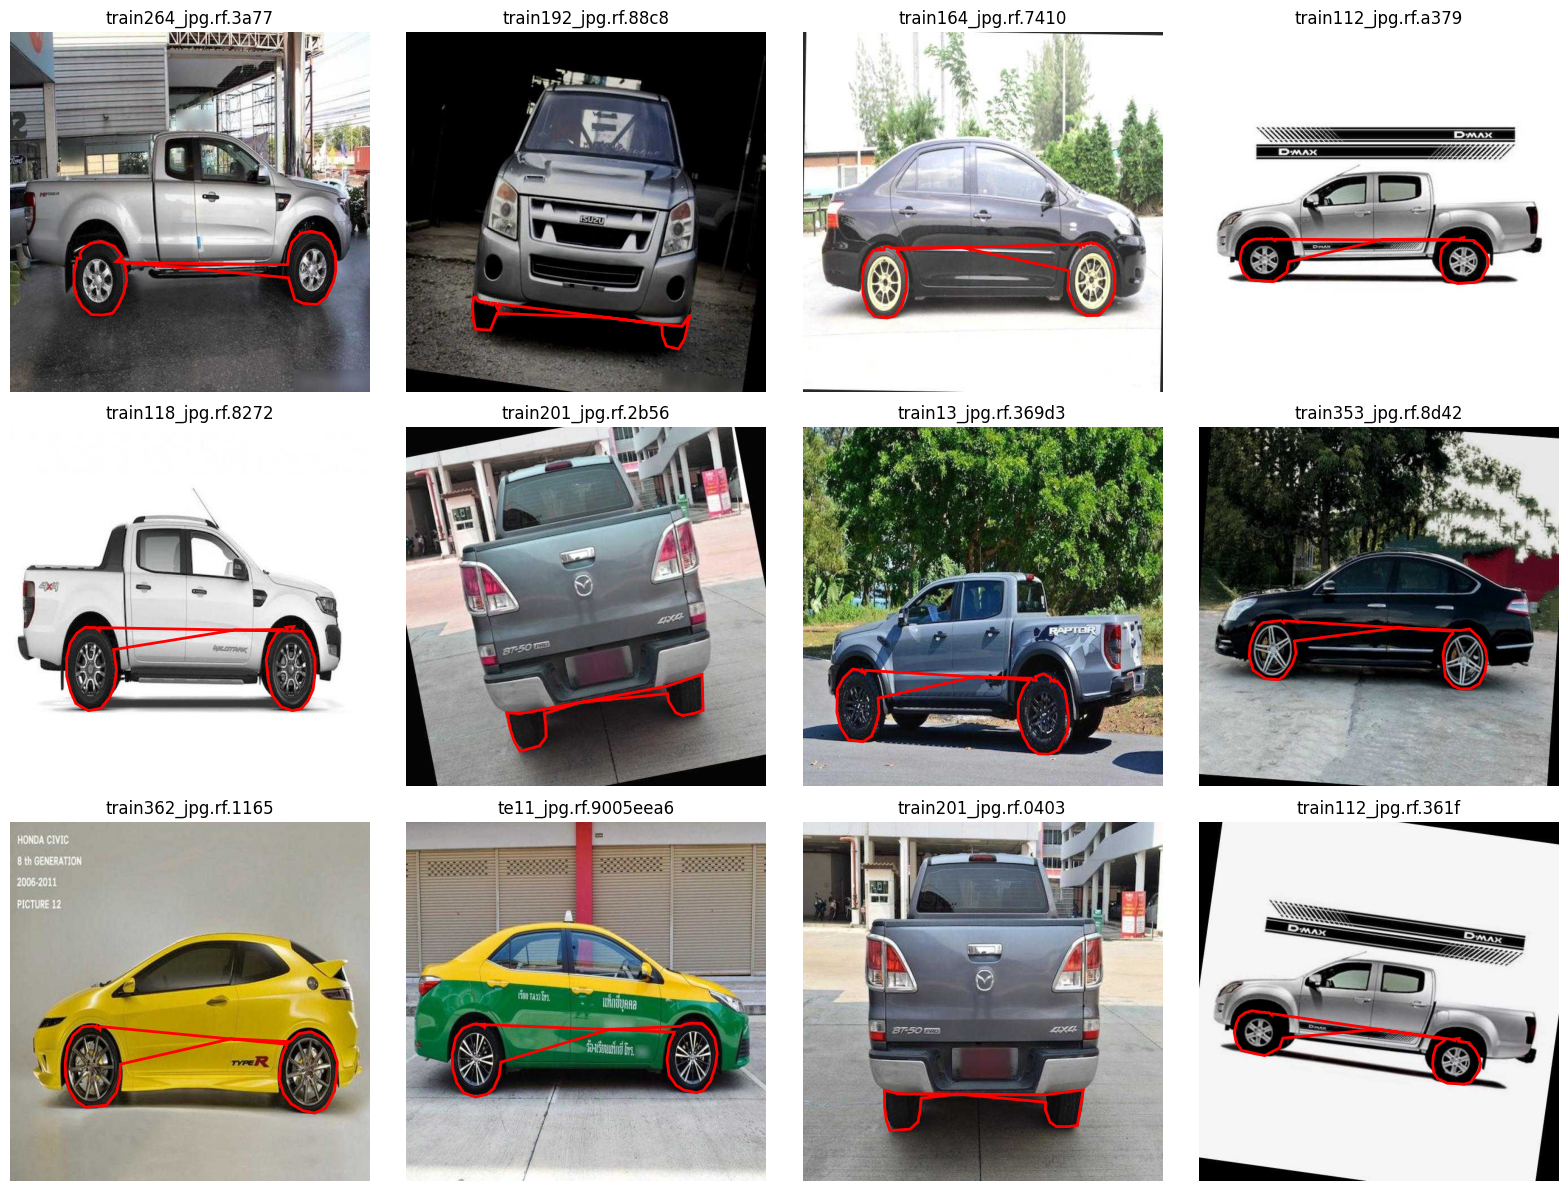

In [32]:
suspicious_val_df = wheel_audit_df[
    (wheel_audit_df["Split"] == "val")
    & (wheel_audit_df["Suspicious"])
].drop_duplicates("Label")

review_samples = suspicious_val_df.sample(
    n=min(12, len(suspicious_val_df)),
    random_state=SEED
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for axis, (_, record) in zip(axes.flat, review_samples.iterrows()):
    image_path = val_images_dir / record["Label"].replace(".txt", ".jpg")
    image = np.array(Image.open(image_path).convert("RGB"))
    height, width = image.shape[:2]

    line = (
        (val_labels_dir / record["Label"])
        .read_text()
        .splitlines()[int(record["Line"])]
    )

    values = list(map(float, line.split()))
    points = np.array(values[1:]).reshape(-1, 2) * [width, height]

    axis.imshow(image)
    axis.add_patch(
        Polygon(points, fill=False, edgecolor="red", linewidth=2)
    )
    axis.set_title(record["Label"][:20])
    axis.axis("off")

plt.tight_layout()
plt.show()

### 8.2 Review Suspicious Training Wheel Annotations

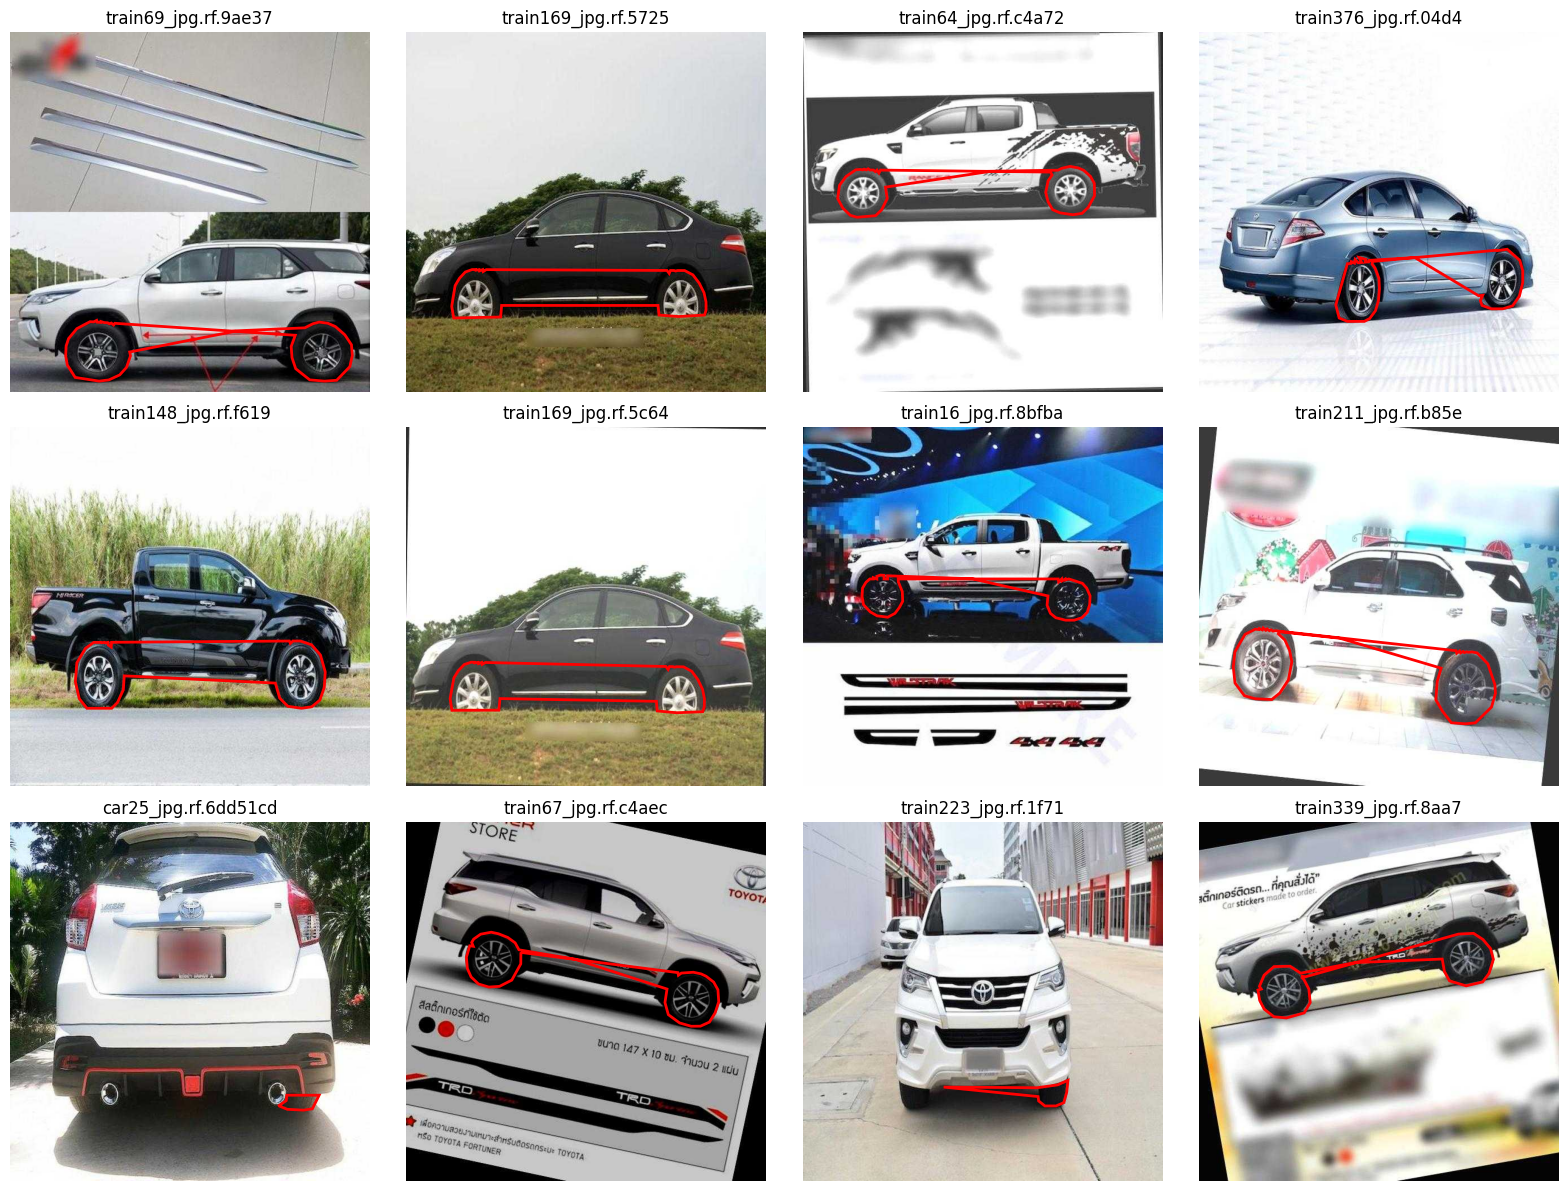

In [33]:
train_labels_dir = CORRECTED_DATA_DIR / "labels" / "train"
train_images_dir = CORRECTED_DATA_DIR / "images" / "train"

suspicious_train_df = wheel_audit_df[
    (wheel_audit_df["Split"] == "train")
    & (wheel_audit_df["Suspicious"])
].drop_duplicates("Label")

review_samples = suspicious_train_df.sample(
    n=12,
    random_state=SEED
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for axis, (_, record) in zip(axes.flat, review_samples.iterrows()):
    image_path = train_images_dir / record["Label"].replace(".txt", ".jpg")
    image = np.array(Image.open(image_path).convert("RGB"))
    height, width = image.shape[:2]

    line = (
        (train_labels_dir / record["Label"])
        .read_text()
        .splitlines()[int(record["Line"])]
    )

    values = list(map(float, line.split()))
    points = np.array(values[1:]).reshape(-1, 2) * [width, height]

    axis.imshow(image)
    axis.add_patch(
        Polygon(points, fill=False, edgecolor="red", linewidth=2)
    )
    axis.set_title(record["Label"][:20])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [37]:
import shutil
from datetime import datetime

BACKUP_DIR = WORK_DIR / f"val_labels_backup_{datetime.now():%Y%m%d}"

if not BACKUP_DIR.exists():
    shutil.copytree(val_labels_dir, BACKUP_DIR)
    print(f"Backed up original val labels to {BACKUP_DIR}")
else:
    print("Backup already exists, skipping.")

Backed up original val labels to /content/data/val_labels_backup_20260909


In [38]:
suspicious_val_full = (
    wheel_audit_df[
        (wheel_audit_df["Split"] == "val") & (wheel_audit_df["Suspicious"])
    ]
    .drop_duplicates(subset=["Label", "Line"])
    .reset_index(drop=True)
)

print(f"Suspicious val wheel instances: {len(suspicious_val_full)}")
print(f"Unique images affected: {suspicious_val_full['Label'].nunique()}")
display(suspicious_val_full)

Suspicious val wheel instances: 29
Unique images affected: 29


,Split,Label,Line,Aspect Ratio,Suspicious
0,val,train353_jpg.rf.8d421d47f88316ae61e84d01ae6c3b...,3,3.477674,True
1,val,train101_jpg.rf.54666b4066ee6ffab74dcaf454a132...,0,3.404293,True
2,val,train298_jpg.rf.09c66f8012323d411a8e36ac7f024f...,0,3.263158,True
3,val,train340_jpg.rf.a6567ac7211672be98b27759bd1a84...,4,3.091371,True
4,val,train122_jpg.rf.2e1f1315a28588300d996219aefb18...,0,3.682332,True
5,val,train377_jpg.rf.e22d6841d60d816f50489be0df118a...,1,3.451859,True
6,val,train318_jpg.rf.f986cd5ce54d1f96fe2c3ac135580e...,2,3.985651,True
7,val,train125_jpg.rf.b2f6d79fca91ad39cfd13c4cf048a3...,1,2.523035,True
8,val,train118_jpg.rf.82723d05d1bb529934cd059ccfcc3a...,0,2.948333,True
9,val,train201_jpg.rf.2b56a1bf140947166399ff991845d6...,5,2.545982,True


In [1]:
def show_review_page(df, start, count=6):
    page = df.iloc[start:start + count]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for axis, (idx, record) in zip(axes.flat, page.iterrows()):
        image_path = val_images_dir / record["Label"].replace(".txt", ".jpg")
        image = np.array(Image.open(image_path).convert("RGB"))
        height, width = image.shape[:2]

        line = (val_labels_dir / record["Label"]).read_text().splitlines()[int(record["Line"])]
        values = list(map(float, line.split()))
        points = np.array(values[1:]).reshape(-1, 2) * [width, height]

        axis.imshow(image)
        axis.add_patch(Polygon(points, fill=False, edgecolor="red", linewidth=2))
        axis.set_title(f"idx={idx} | {record['Label'][:18]} | AR={record['Aspect Ratio']:.2f}")
        axis.axis("off")

    for axis in axes.flat[len(page):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

show_review_page(suspicious_val_full, start=0)

### 8.3 Identify Wheel Annotations for Manual Correction

In [17]:
wheel_class_id = 12
wheel_review = []

for split in ["train", "val", "test"]:
    labels_dir = CORRECTED_DATA_DIR / "labels" / split

    for label_path in labels_dir.glob("*.txt"):
        lines = label_path.read_text().splitlines()

        for line_number, line in enumerate(lines):
            values = list(map(float, line.split()))

            if int(values[0]) != wheel_class_id:
                continue

            x_points = values[1::2]
            y_points = values[2::2]

            polygon_width = max(x_points) - min(x_points)
            polygon_height = max(y_points) - min(y_points)

            if polygon_height == 0:
                continue

            aspect_ratio = polygon_width / polygon_height

            if aspect_ratio > 2.5:
                wheel_review.append({
                    "Split": split,
                    "Label": label_path.name,
                    "Line": line_number,
                    "Aspect Ratio": round(aspect_ratio, 2)
                })

wheel_review_df = pd.DataFrame(wheel_review)

wheel_review_summary_df = (
    wheel_review_df
    .groupby("Split")
    .agg(
        Images=("Label", "nunique"),
        Wheel_Polygons=("Label", "size")
    )
    .reset_index()
)

display(wheel_review_summary_df)

print("Total images to review:", wheel_review_df["Label"].nunique())
print("Total wheel polygons to review:", len(wheel_review_df))

,Split,Images,Wheel_Polygons
0,test,22,23
1,train,98,98
2,val,29,29


Total images to review: 149
Total wheel polygons to review: 150


### 8.4 Create Wheel Annotation Review Dataset

In [9]:
REVIEW_DIR = Path("/content/wheel-annotation-review")
REVIEW_IMAGES_DIR = REVIEW_DIR / "images" / "train"
REVIEW_LABELS_DIR = REVIEW_DIR / "labels" / "train"

if REVIEW_DIR.exists():
    shutil.rmtree(REVIEW_DIR)

REVIEW_IMAGES_DIR.mkdir(parents=True)
REVIEW_LABELS_DIR.mkdir(parents=True)

review_images_df = (
    wheel_review_df[["Split", "Label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

mapping_records = []

for _, row in review_images_df.iterrows():
    split = row["Split"]
    label_name = row["Label"]
    original_stem = Path(label_name).stem

    original_label = (
        CORRECTED_DATA_DIR / "labels" / split / label_name
    )

    image_matches = list(
        (CORRECTED_DATA_DIR / "images" / split)
        .glob(f"{original_stem}.*")
    )

    original_image = image_matches[0]
    review_stem = f"{split}__{original_stem}"

    review_image = (
        REVIEW_IMAGES_DIR
        / f"{review_stem}{original_image.suffix}"
    )

    review_label = (
        REVIEW_LABELS_DIR
        / f"{review_stem}.txt"
    )

    shutil.copy2(original_image, review_image)
    shutil.copy2(original_label, review_label)

    mapping_records.append({
        "Split": split,
        "Original Image": original_image.name,
        "Original Label": original_label.name,
        "Review Image": review_image.name,
        "Review Label": review_label.name
    })

review_mapping_df = pd.DataFrame(mapping_records)

print("Images copied:", len(review_mapping_df))
print("Labels copied:", len(list(REVIEW_LABELS_DIR.glob("*.txt"))))

In [19]:
with CORRECTED_YAML.open("r", encoding="utf-8") as yaml_file:
    corrected_config = yaml.safe_load(yaml_file)

review_config = {
    "path": ".",
    "train": "images/train",
    "names": corrected_config["names"]
}

review_yaml_path = REVIEW_DIR / "data.yaml"

with review_yaml_path.open("w", encoding="utf-8") as yaml_file:
    yaml.safe_dump(
        review_config,
        yaml_file,
        sort_keys=False,
        allow_unicode=True
    )

review_image_paths = sorted(
    f"images/train/{image_path.name}"
    for image_path in REVIEW_IMAGES_DIR.iterdir()
)

(REVIEW_DIR / "train.txt").write_text(
    "\n".join(review_image_paths),
    encoding="utf-8"
)

mapping_path = Path(
    "/content/drive/MyDrive/data/wheel-annotation-review-mapping.csv"
)

review_mapping_df.to_csv(
    mapping_path,
    index=False
)

zip_base_path = Path(
    "/content/drive/MyDrive/data/wheel-annotation-review"
)

zip_path = shutil.make_archive(
    str(zip_base_path),
    "zip",
    root_dir=REVIEW_DIR
)

print("Review ZIP:", zip_path)
print("Mapping file:", mapping_path)
print("Images in ZIP:", len(review_image_paths))

Review ZIP: /content/drive/MyDrive/data/wheel-annotation-review.zip
Mapping file: /content/drive/MyDrive/data/wheel-annotation-review-mapping.csv
Images in ZIP: 149


### 8.5 Apply First-Round Wheel Corrections

In [6]:
from pathlib import Path
import zipfile

corrections_zip = Path(
    "/content/drive/MyDrive/data/wheel-annotation-corrections.zip"
)

corrections_dir = Path(
    "/content/wheel-annotation-corrections"
)

with zipfile.ZipFile(corrections_zip, "r") as zip_file:
    zip_file.extractall(corrections_dir)

corrected_label_files = list(
    corrections_dir.rglob("*.txt")
)

print("Corrected label files:", len(corrected_label_files))
print("First file:", corrected_label_files[0])

Corrected label files: 150
First file: /content/wheel-annotation-corrections/train.txt


In [7]:
labels_dir = corrections_dir / "labels"

corrected_label_files = sorted(
    labels_dir.rglob("*.txt")
)

print("Corrected annotation files:", len(corrected_label_files))
print("First annotation:", corrected_label_files[0].name)
print("Last annotation:", corrected_label_files[-1].name)

Corrected annotation files: 149
First annotation: test__te86_jpg.rf.2a3731c691c073562603e3ceb13d7c06.txt
Last annotation: val__train377_jpg.rf.e22d6841d60d816f50489be0df118a7b.txt


### 8.6 Restore the Corrected Dataset

In [7]:
from pathlib import Path
from zipfile import ZipFile

saved_dataset_zip = Path(
    "/content/drive/MyDrive/data/carparts-corrected-expanded.zip"
)

work_dir = Path("/content/data")
work_dir.mkdir(parents=True, exist_ok=True)

with ZipFile(saved_dataset_zip, "r") as zip_file:
    zip_file.extractall(work_dir)

dataset_dir = Path(
    "/content/data/carparts-corrected-expanded"
)

print("Dataset restored:", dataset_dir.exists())

for split_name in ["train", "val", "test"]:
    labels_dir = dataset_dir / "labels" / split_name
    print(split_name, "labels:", len(list(labels_dir.glob("*.txt"))))

Dataset restored: True
train labels: 3269
val labels: 561
test labels: 554


In [8]:
from pathlib import Path
import pandas as pd

dataset_dir = Path(
    "/content/data/carparts-corrected-expanded"
)

matched_files = []

for corrected_file in corrected_label_files:
    split_name, original_name = corrected_file.stem.split("__", 1)

    original_label = (
        dataset_dir
        / "labels"
        / split_name
        / f"{original_name}.txt"
    )

    matched_files.append({
        "Split": split_name,
        "Corrected File": corrected_file.name,
        "Original File": original_label.name,
        "Found": original_label.exists()
    })

matches_df = pd.DataFrame(matched_files)

display(
    matches_df.groupby(["Split", "Found"])
    .size()
    .reset_index(name="Files")
)

print("Matched files:", matches_df["Found"].sum())
print("Missing files:", (~matches_df["Found"]).sum())

In [12]:
replaced_files = 0
missing_files = []

for corrected_file in corrected_label_files:
    split_name, original_name = corrected_file.stem.split("__", 1)

    original_label = (
        dataset_dir
        / "labels"
        / split_name
        / f"{original_name}.txt"
    )

    if original_label.exists():
        shutil.copy2(corrected_file, original_label)
        replaced_files += 1
    else:
        missing_files.append(corrected_file.name)

print("Replaced label files:", replaced_files)
print("Missing label files:", len(missing_files))

Replaced label files: 149
Missing label files: 0


In [19]:
wheel_class_id = 12
wheel_audit = []

for split_name in ["train", "val", "test"]:
    labels_dir = dataset_dir / "labels" / split_name

    for label_file in labels_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            values = list(map(float, line.split()))

            if int(values[0]) != wheel_class_id:
                continue

            x_points = values[1::2]
            y_points = values[2::2]

            polygon_width = max(x_points) - min(x_points)
            polygon_height = max(y_points) - min(y_points)
            aspect_ratio = polygon_width / polygon_height

            wheel_audit.append({
                "Split": split_name,
                "Label": label_file.name,
                "Aspect Ratio": aspect_ratio,
                "Suspicious": aspect_ratio > 2.5
            })

wheel_audit_df = pd.DataFrame(wheel_audit)

audit_summary = (
    wheel_audit_df
    .groupby("Split")
    .agg(
        Wheel_Polygons=("Label", "count"),
        Suspicious=("Suspicious", "sum")
    )
    .reset_index()
)

display(audit_summary)

print(
    "Total suspicious wheel polygons:",
    wheel_audit_df["Suspicious"].sum()
)

,Split,Wheel_Polygons,Suspicious
0,test,152,2
1,train,1934,6
2,val,174,0


Total suspicious wheel polygons: 8


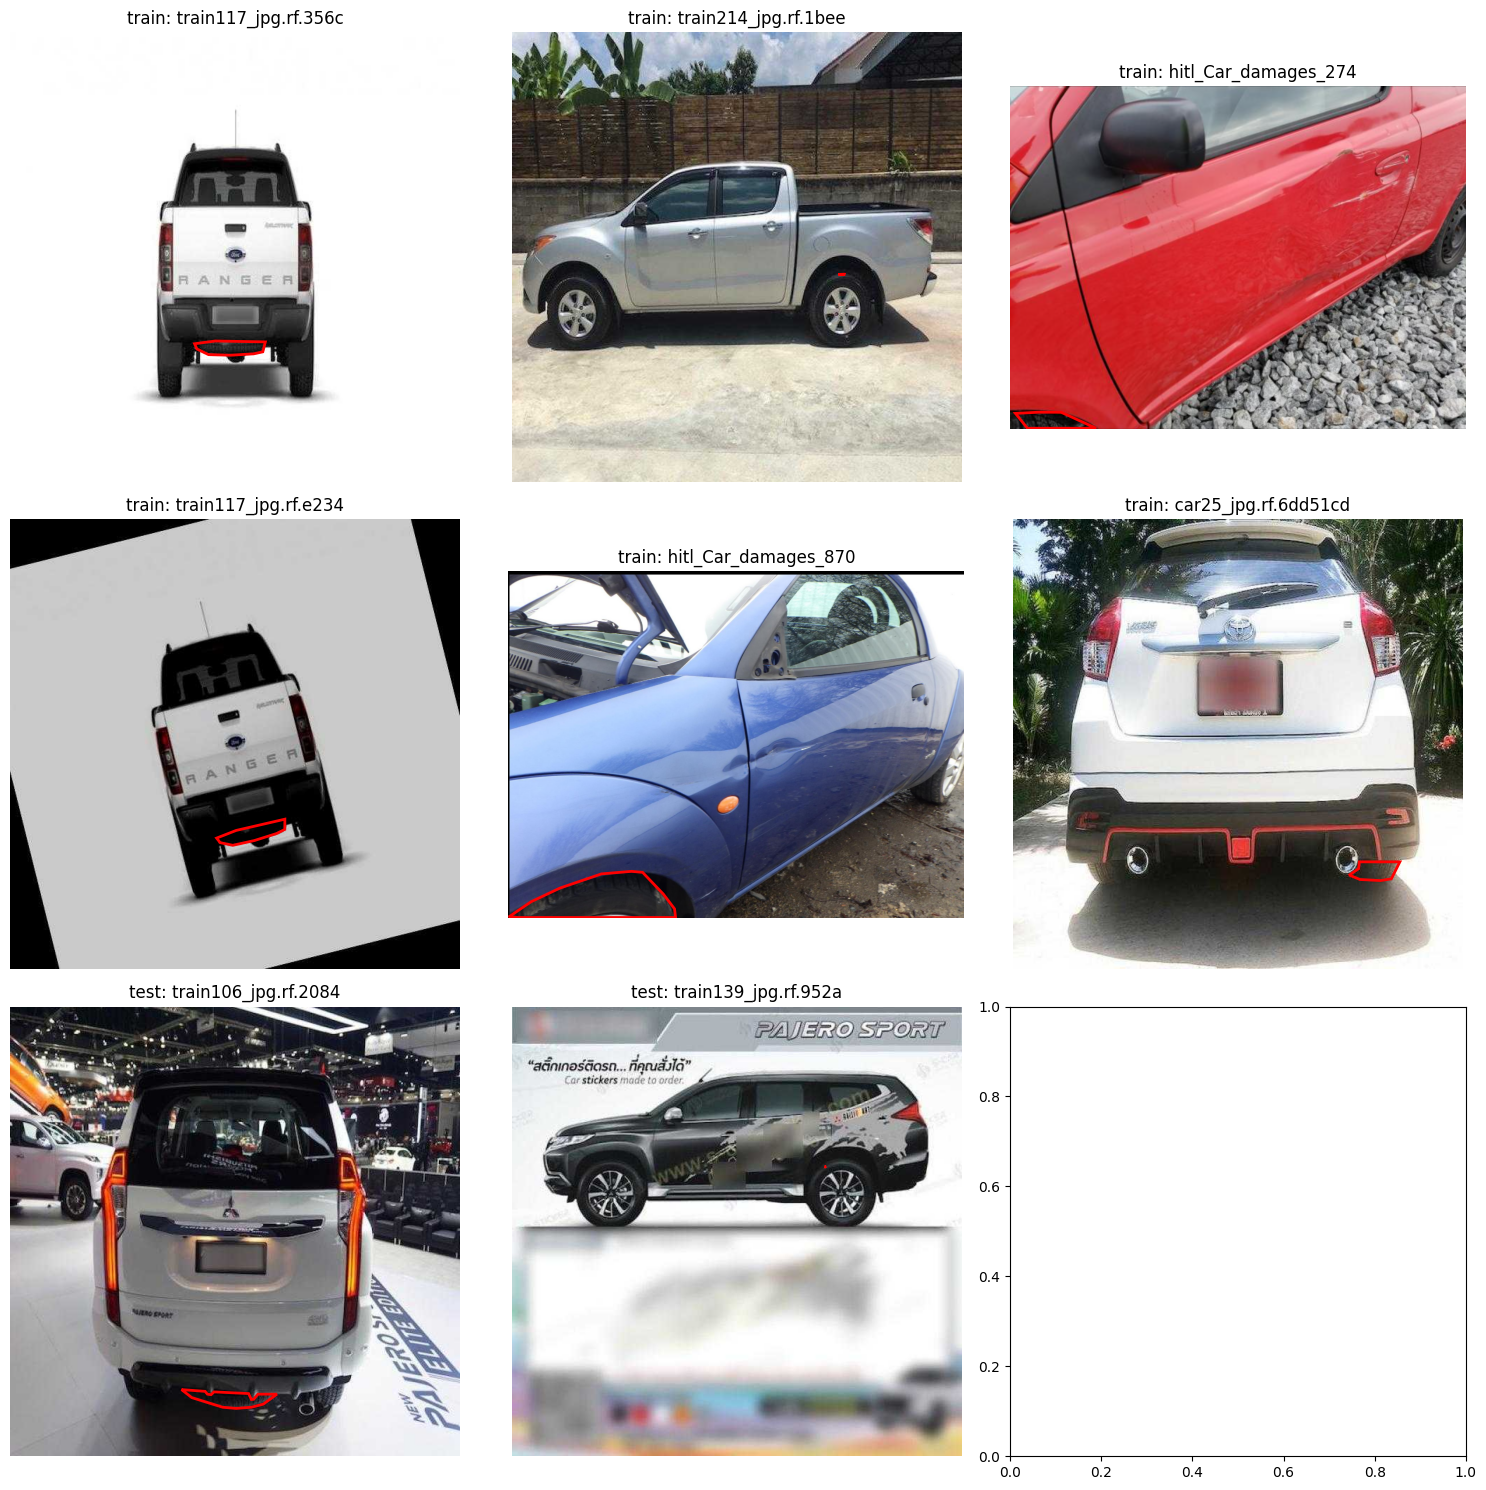

In [20]:
suspicious_df = wheel_audit_df[
    wheel_audit_df["Suspicious"]
].reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for index, row in suspicious_df.iterrows():
    label_path = (
        dataset_dir
        / "labels"
        / row["Split"]
        / row["Label"]
    )

    image_dir = dataset_dir / "images" / row["Split"]
    image_name = Path(row["Label"]).stem

    image_path = image_dir / f"{image_name}.jpg"

    if not image_path.exists():
        image_path = image_dir / f"{image_name}.png"

    image = np.array(Image.open(image_path).convert("RGB"))
    height, width = image.shape[:2]

    axes[index].imshow(image)

    for line in label_path.read_text().splitlines():
        values = list(map(float, line.split()))

        if int(values[0]) != wheel_class_id:
            continue

        points = np.array(values[1:]).reshape(-1, 2)
        polygon_width = points[:, 0].max() - points[:, 0].min()
        polygon_height = points[:, 1].max() - points[:, 1].min()

        if polygon_width / polygon_height > 2.5:
            points = points * [width, height]

            axes[index].add_patch(
                Polygon(
                    points,
                    fill=False,
                    edgecolor="red",
                    linewidth=2
                )
            )

    axes[index].set_title(
        f'{row["Split"]}: {image_name[:20]}'
    )
    axes[index].axis("off")

plt.tight_layout()
plt.show()

### 8.7 Export Remaining Wheel Cases for Manual Review

In [5]:
review_dir = Path("/content/wheel-second-review")
review_images_dir = review_dir / "images" / "train"
review_labels_dir = review_dir / "labels" / "train"

if review_dir.exists():
    shutil.rmtree(review_dir)

review_images_dir.mkdir(parents=True)
review_labels_dir.mkdir(parents=True)

remaining_cases = suspicious_df.drop_duplicates(
    ["Split", "Label"]
)

train_list = []

for _, row in remaining_cases.iterrows():
    split_name = row["Split"]
    label_name = row["Label"]
    image_name = Path(label_name).stem

    source_label = (
        dataset_dir / "labels" / split_name / label_name
    )

    source_image = None

    for extension in [".jpg", ".jpeg", ".png"]:
        possible_image = (
            dataset_dir
            / "images"
            / split_name
            / f"{image_name}{extension}"
        )

        if possible_image.exists():
            source_image = possible_image
            break

    new_name = f"{split_name}__{image_name}"

    shutil.copy2(
        source_label,
        review_labels_dir / f"{new_name}.txt"
    )

    shutil.copy2(
        source_image,
        review_images_dir / f"{new_name}{source_image.suffix}"
    )

    train_list.append(
        f"images/train/{new_name}{source_image.suffix}"
    )

dataset_yaml = next(dataset_dir.glob("*.yaml"))

with dataset_yaml.open("r") as file:
    dataset_config = yaml.safe_load(file)

review_config = {
    "path": ".",
    "train": "images/train",
    "names": dataset_config["names"]
}

with (review_dir / "data.yaml").open("w") as file:
    yaml.safe_dump(review_config, file, sort_keys=False)

(review_dir / "train.txt").write_text(
    "\n".join(train_list)
)

output_zip = Path(
    "/content/drive/MyDrive/data/wheel-second-review"
)

shutil.make_archive(
    str(output_zip),
    "zip",
    root_dir=review_dir
)

print("Images exported:", len(train_list))
print("Saved to:", f"{output_zip}.zip")

### 8.8 Apply Second-Round Wheel Corrections

In [22]:
second_corrections_zip = Path(
    "/content/drive/MyDrive/data/wheel-second-review-corrections.zip"
)

second_corrections_dir = Path(
    "/content/wheel-second-review-corrections"
)

with ZipFile(second_corrections_zip, "r") as zip_file:
    zip_file.extractall(second_corrections_dir)

second_corrected_labels = sorted(
    (second_corrections_dir / "labels").rglob("*.txt")
)

print("Corrected annotation files:", len(second_corrected_labels))

Corrected annotation files: 9


In [18]:
replaced_files = 0
missing_files = []

for corrected_file in second_corrected_labels:
    split_name, original_name = corrected_file.stem.split("__", 1)

    original_label = (
        dataset_dir
        / "labels"
        / split_name
        / f"{original_name}.txt"
    )

    if original_label.exists():
        shutil.copy2(corrected_file, original_label)
        replaced_files += 1
    else:
        missing_files.append(corrected_file.name)

print("Replaced label files:", replaced_files)
print("Missing label files:", len(missing_files))

Replaced label files: 9
Missing label files: 0


### 8.9 Package the Wheel-Corrected Dataset

In [10]:
final_dataset_zip = Path(
    "/content/drive/MyDrive/data/"
    "carparts-corrected-expanded-wheel-fixed.zip"
)

archive_path = final_dataset_zip.with_suffix("")

shutil.make_archive(
    str(archive_path),
    "zip",
    root_dir=dataset_dir.parent,
    base_dir=dataset_dir.name
)

print("Final dataset saved:", final_dataset_zip)
print(
    "Size (MB):",
    round(final_dataset_zip.stat().st_size / 1_000_000, 1)
)

Final dataset saved: /content/drive/MyDrive/data/carparts-corrected-expanded-wheel-fixed.zip
Size (MB): 645.2


In [11]:
cache_files = list(dataset_dir.rglob("*.cache"))

for cache_file in cache_files:
    cache_file.unlink()

print("Cache files removed:", len(cache_files))

Cache files removed: 2


### 8.10 Consolidated Final Dataset Rebuild

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/data")

BASE_DATA_ZIP = DATA_DIR / "carparts-corrected-expanded.zip"

CORRECTION_ZIPS = [
    DATA_DIR / "wheel-annotation-corrections.zip",
    DATA_DIR / "wheel-second-review-corrections.zip"
]

WORK_DIR = Path("/content/wheel-fix-rebuild")

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

WORK_DIR.mkdir()

with ZipFile(BASE_DATA_ZIP, "r") as zip_file:
    zip_file.extractall(WORK_DIR)

dataset_dir = WORK_DIR / "carparts-corrected-expanded"

for correction_number, correction_zip in enumerate(
    CORRECTION_ZIPS,
    start=1
):
    correction_dir = WORK_DIR / f"corrections-{correction_number}"

    with ZipFile(correction_zip, "r") as zip_file:
        zip_file.extractall(correction_dir)

    corrected_labels = list(
        (correction_dir / "labels").rglob("*.txt")
    )

    replaced_files = 0

    for corrected_file in corrected_labels:
        split_name, original_name = corrected_file.stem.split(
            "__",
            1
        )

        original_label = (
            dataset_dir
            / "labels"
            / split_name
            / f"{original_name}.txt"
        )

        if original_label.exists():
            shutil.copy2(corrected_file, original_label)
            replaced_files += 1

    print(
        f"Corrections {correction_number}:",
        replaced_files,
        "labels replaced"
    )

Corrections 1: 149 labels replaced
Corrections 2: 9 labels replaced


In [5]:
for split in ["train", "val", "test"]:
    labels_dir = dataset_dir / "labels" / split
    wheel_count = 0

    for label_file in labels_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            if line.split()[0] == "12":
                wheel_count += 1

    print(split, "wheel polygons:", wheel_count)

train wheel polygons: 1934
val wheel polygons: 174
test wheel polygons: 152


In [6]:
FINAL_ZIP = (
    DATA_DIR
    / "carparts-corrected-expanded-wheel-fixed-v2.zip"
)

archive_path = FINAL_ZIP.with_suffix("")

shutil.make_archive(
    str(archive_path),
    "zip",
    root_dir=dataset_dir.parent,
    base_dir=dataset_dir.name
)

print("Saved:", FINAL_ZIP)
print(
    "Size (MB):",
    round(FINAL_ZIP.stat().st_size / 1_000_000, 1)
)

Saved: /content/drive/MyDrive/data/carparts-corrected-expanded-wheel-fixed-v2.zip
Size (MB): 645.1


### 8.11 Handoff to Notebook 09

The successful wheel-fixed baseline training and validation results are documented in Notebook 09. Hyperparameter tuning is intentionally deferred until the remaining missing-wheel annotation candidates have been reviewed.